## **Project: Analyzing Hotel Booking Cancellation Patterns**

**Dataset:** This analysis utilizes the "Hotel Booking Demand Dataset," which contains detailed booking information for two distinct hotel types: a Resort Hotel (H1) and a City Hotel (H2). The dataset, originally published by Nuno Antonio, Ana Almeida, and Luis Nunes in *Data in Brief* (2019), provides a comprehensive view of hotel reservation data, encompassing over 100,000 bookings and more than 30 distinct attributes per booking. [dataset](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand?select=hotel_bookings.csv)

Key information within the dataset includes:
*   **Booking Details:** Lead time, stay duration (weekend/week nights), arrival dates (year, month, day, week number).
*   **Guest Information:** Number of adults/children/babies, country of origin, customer type (e.g., Transient, Contract, Group), repeated guest status, previous cancellation history.
*   **Reservation Specifics:** Meal type, market segment ("Travel Agents", "Tour Operators", etc.), distribution channel, reserved and assigned room types, deposit type, average daily rate (ADR), required parking spaces, special requests.
*   **Outcome Information:** Booking status (canceled or not), reservation status (Canceled, Check-Out, No-Show).


**Problem:** Hotel booking cancellations represent a significant operational challenge and a direct source of lost revenue for both City and Resort hotels. High cancellation rates can lead to unsold inventory, complicate resource planning (staffing, supplies), and ultimately reduce profitability. Effectively managing and mitigating cancellations is therefore critical for sustained hotel success.

**Focused Analytical Question:** For both the City Hotel and Resort Hotel (`hotel`), what are the key booking attributes (e.g., `lead_time`, `adr`, `deposit_type`, `market_segment`, `distribution_channel`, stay dates/duration) and customer characteristics (e.g., `is_repeated_guest`, `country` of origin, `customer_type`, `previous_cancellations`) that are most strongly associated with bookings being canceled (`is_canceled` = 1)? Are these patterns significantly different between the two types of hotels?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

file_path = 'sample_data/hotel_bookings.csv'
df = pd.read_csv(file_path)

print("First 5 rows of the dataset:")
print(df.head())

print(f"\nDataset dimensions (rows, columns): {df.shape}")

print("\nDataset info (columns, non-null counts, data types):")
df.info()

print("\nColumn names:")
print(df.columns)

First 5 rows of the dataset:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2

## **Data Cleaning and Preparation**

Missing values:
*   children (4 missing)
*   country (488 missing)
*   agent (16,340 missing)
*   company (112,593 missing)

In [ ]:
df['children'].fillna(0, inplace=True)

df['country'].fillna('Unknown', inplace=True)

df['agent'].fillna(0, inplace=True)

df['children'] = df['children'].astype(int)

df['agent'] = df['agent'].astype(int)

# convert date column
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

print(f"Number of duplicate rows: {df.duplicated().sum()}")

print(f"Unique meal types: {df['meal'].unique()}")

# check for invalid 'adr' values
print(f"ADR values below zero: {df[df['adr'] < 0]['adr'].count()}")

# check for bookings with zero guests
print(f"Bookings with zero guests: {len(df[(df['adults']==0) & (df['children']==0) & (df['babies']==0)])}")

# remove rows with zero guests
df.drop(df[(df['adults']==0) & (df['children']==0) & (df['babies']==0)].index, inplace=True)

# create total stay duration
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

Number of duplicate rows: 31994
Unique meal types: ['BB' 'FB' 'HB' 'SC' 'Undefined']
ADR values below zero: 1
Bookings with zero guests: 180


<ipython-input-38-b45bbd3b1e62>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(0, inplace=True)
<ipython-input-38-b45bbd3b1e62>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.meth

In [ ]:
print(f"Original shape before dropping duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")
print(f"Dropped {31980} duplicate rows.\n")

print(f"Shape before dropping negative ADR: {df.shape}")
df = df[df['adr'] >= 0]
print(f"Shape after dropping negative ADR: {df.shape}")
print("Removed 1 row with negative ADR.\n")

if df['company'].isnull().sum() > 0:
     print("Warning: 'company' column still has NaNs. Filling with 0.\n")
     df['company'].fillna(0, inplace=True)


if df['company'].dtype == 'float':
     print("Warning: 'company' column type is float. Converting to int.\n")
     df['company'] = df['company'].astype(int)

if 'total_guests' not in df.columns:
    print("Creating 'total_guests' column.\n")
    df['total_guests'] = df['adults'] + df['children'] + df['babies']
else:
    print("'total_guests' column already exists.\n")


Original shape before dropping duplicates: (119210, 33)
Shape after dropping duplicates: (87230, 33)
Dropped 31980 duplicate rows.

Shape before dropping negative ADR: (87230, 33)
Shape after dropping negative ADR: (87229, 33)
Removed 1 row with negative ADR.



Creating 'total_guests' column.



<ipython-input-39-c757a84a53f1>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['company'].fillna(0, inplace=True)
<ipython-input-39-c757a84a53f1>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['company'].fillna(0, inplace=True)
<ipython-input-39-c757a84a53f1>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

## **EDA**


# **Overall Cancellation Analysis:**


--- Overall Cancellation Analysis ---
Total Bookings in Cleaned Dataset: 87229
Canceled Bookings: 24009
Overall Cancellation Rate: 27.52%

--- Cancellation Rate by Hotel Type ---
Booking Counts by Hotel Type:
hotel
City Hotel      53274
Resort Hotel    33955
Name: count, dtype: int64

Cancellation Rate (%) by Hotel Type:
hotel
City Hotel      30.10
Resort Hotel    23.48
Name: is_canceled, dtype: float64


<ipython-input-40-a34640998503>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='viridis')


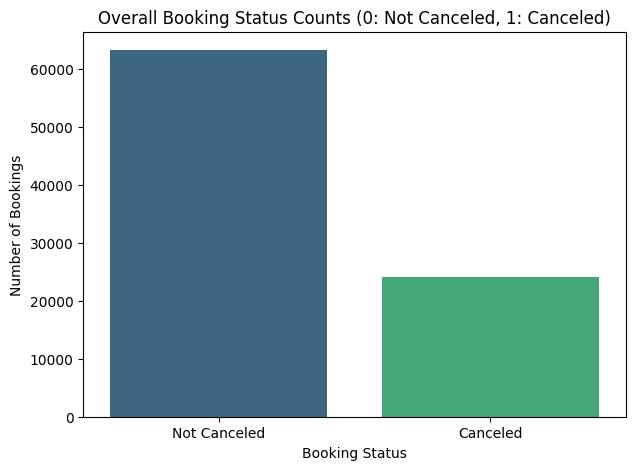

<ipython-input-40-a34640998503>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hotel', y='is_canceled', data=cancellation_rate_by_hotel_df, palette='viridis')


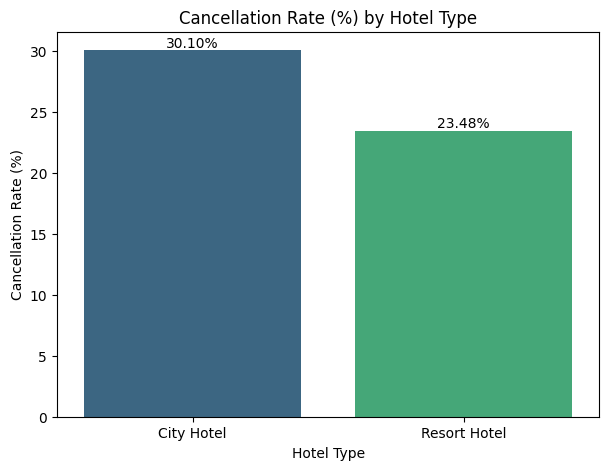

In [ ]:
print("--- Overall Cancellation Analysis ---")
total_bookings = len(df)
canceled_bookings = df['is_canceled'].sum()
overall_cancellation_rate = (canceled_bookings / total_bookings) * 100

print(f"Total Bookings in Cleaned Dataset: {total_bookings}")
print(f"Canceled Bookings: {canceled_bookings}")
print(f"Overall Cancellation Rate: {overall_cancellation_rate:.2f}%")

print("\n--- Cancellation Rate by Hotel Type ---")
cancellation_rate_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100

booking_counts_by_hotel = df['hotel'].value_counts()

print("Booking Counts by Hotel Type:")
print(booking_counts_by_hotel)
print("\nCancellation Rate (%) by Hotel Type:")
print(cancellation_rate_by_hotel.round(2))

# Overall Counts of Canceled vs. Not Canceled
plt.figure(figsize=(7, 5))
sns.countplot(x='is_canceled', data=df, palette='viridis')
plt.title('Overall Booking Status Counts (0: Not Canceled, 1: Canceled)')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')
plt.xticks(ticks=[0, 1], labels=['Not Canceled', 'Canceled'])
plt.show()

# Cancellation Rate (%) by Hotel Type
plt.figure(figsize=(7, 5))
cancellation_rate_by_hotel_df = cancellation_rate_by_hotel.reset_index()

sns.barplot(x='hotel', y='is_canceled', data=cancellation_rate_by_hotel_df, palette='viridis')
plt.title('Cancellation Rate (%) by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
for index, row in cancellation_rate_by_hotel_df.iterrows():
    plt.text(index, row['is_canceled'], f"{row['is_canceled']:.2f}%", color='black', ha="center", va='bottom')

plt.show()

# **Numerical Feature Analysis vs. Cancellation**


--- Numerical Feature Analysis vs. Cancellation ---

-- Lead Time Analysis --
Average Lead Time by Booking Status:
is_canceled
0     70.18
1    105.74
Name: lead_time, dtype: float64
0: Not Canceled, 1: Canceled


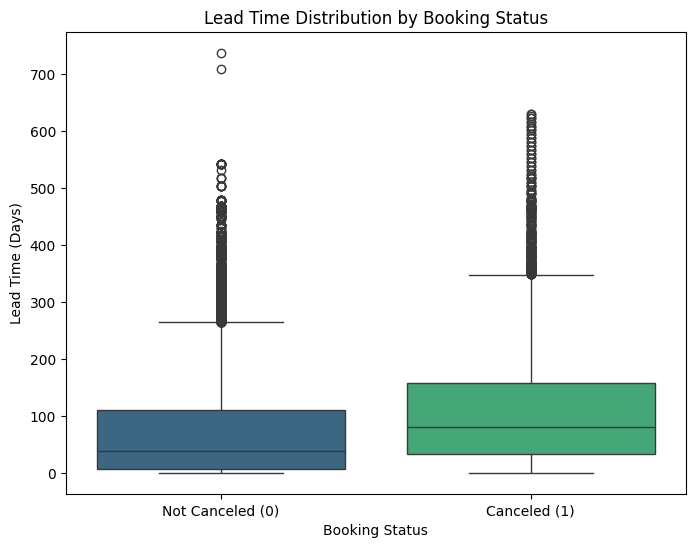

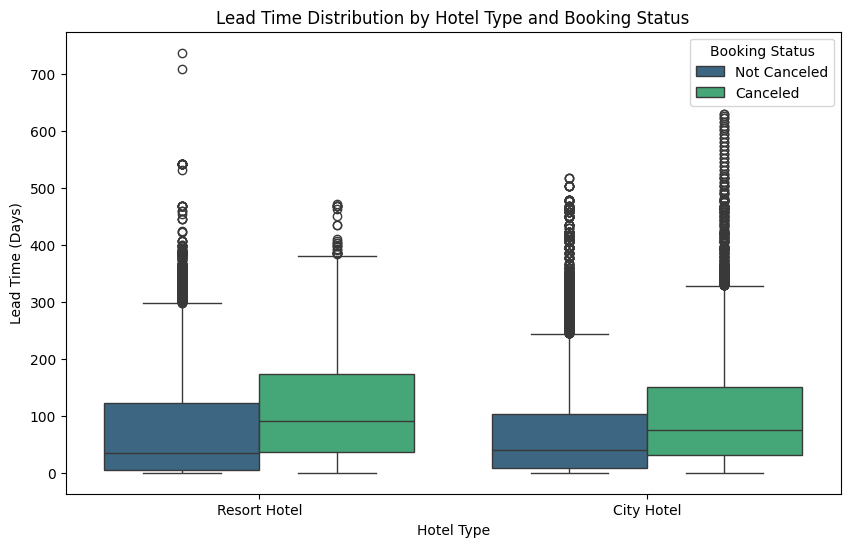

In [ ]:
print("\n--- Numerical Feature Analysis vs. Cancellation ---")

print("\n-- Lead Time Analysis --")
avg_lead_time = df.groupby('is_canceled')['lead_time'].mean()
print("Average Lead Time by Booking Status:")
print(avg_lead_time.round(2))
print(f"0: Not Canceled, 1: Canceled")

# Box Plot of Lead Time vs. Cancellation
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df, palette='viridis', hue='is_canceled', legend=False)
plt.title('Lead Time Distribution by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time (Days)')
plt.xticks(ticks=[0, 1], labels=['Not Canceled (0)', 'Canceled (1)'])
plt.show()

# Faceted Box Plots by Hotel Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='hotel', y='lead_time', hue='is_canceled', data=df, palette='viridis')
plt.title('Lead Time Distribution by Hotel Type and Booking Status')
plt.xlabel('Hotel Type')
plt.ylabel('Lead Time (Days)')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Not Canceled', 'Canceled'], title='Booking Status')
plt.show()


*Longer Lead Time = Higher Cancellation Risk*


-- Average Daily Rate (ADR) Analysis --
Average ADR by Booking Status:
is_canceled
0    102.22
1    117.85
Name: adr, dtype: float64
0: Not Canceled, 1: Canceled


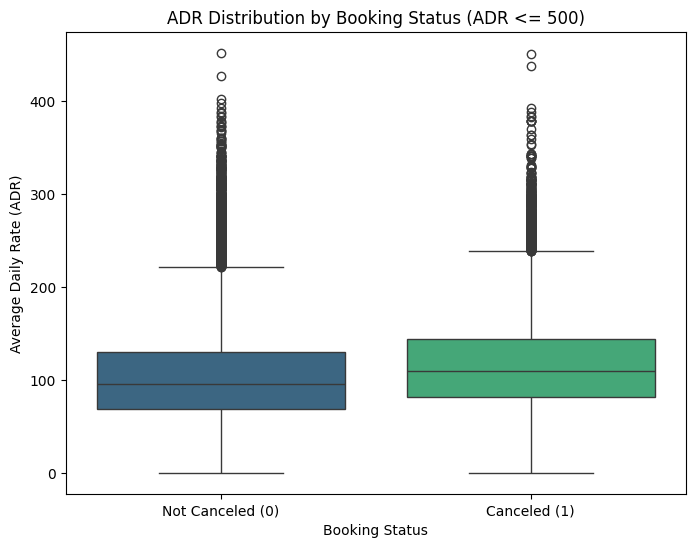

In [ ]:
print("\n-- Average Daily Rate (ADR) Analysis --")
avg_adr = df.groupby('is_canceled')['adr'].mean()
print("Average ADR by Booking Status:")
print(avg_adr.round(2))
print(f"0: Not Canceled, 1: Canceled")

# Box Plot of ADR vs. Cancellation
# adr_upper_limit = df['adr'].quantile(0.99)
adr_upper_limit =500

plt.figure(figsize=(8, 6))
sns.boxplot(x='is_canceled', y='adr', data=df[df['adr'] <= adr_upper_limit], palette='viridis', hue='is_canceled', legend=False)
plt.title(f'ADR Distribution by Booking Status (ADR <= {adr_upper_limit})')
plt.xlabel('Booking Status')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(ticks=[0, 1], labels=['Not Canceled (0)', 'Canceled (1)'])
plt.show()

*Higher Price, Slightly Higher Risk to cancellation (not a prime reason)*


-- Total Stay Duration Analysis --
Note: Filtered out 591 bookings with 0 total stay nights for this analysis.
Average Total Stay Duration by Booking Status (for stays > 0 nights):
is_canceled
0    3.52
1    4.01
Name: total_stay, dtype: float64
0: Not Canceled, 1: Canceled
(Note: Total Stay Box plot visualizes durations up to 14.0 nights for clarity)


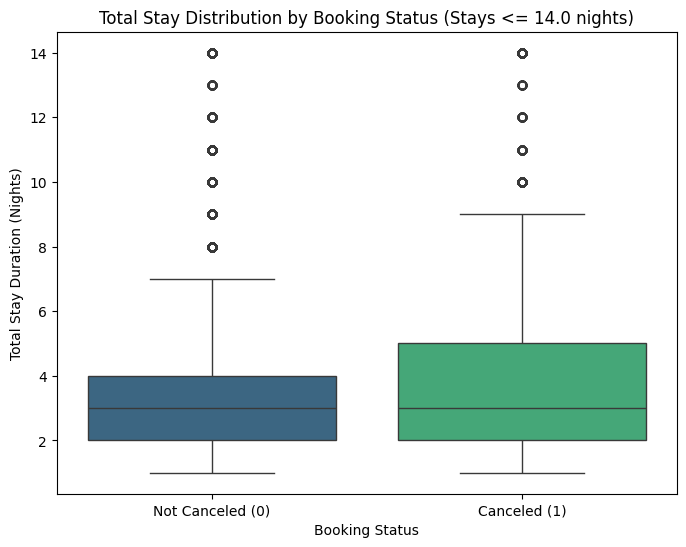

In [ ]:
print("\n-- Total Stay Duration Analysis --")
df_filtered_stay = df[df['total_stay'] > 0]
if len(df_filtered_stay) < len(df):
     print(f"Note: Filtered out {len(df) - len(df_filtered_stay)} bookings with 0 total stay nights for this analysis.")

avg_total_stay = df_filtered_stay.groupby('is_canceled')['total_stay'].mean()
print("Average Total Stay Duration by Booking Status (for stays > 0 nights):")
print(avg_total_stay.round(2))
print(f"0: Not Canceled, 1: Canceled")

# Box plot of Total Stay vs. Cancellation
stay_upper_limit = df_filtered_stay['total_stay'].quantile(0.99)
print(f"(Note: Total Stay Box plot visualizes durations up to {stay_upper_limit} nights for clarity)")
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_canceled', y='total_stay', data=df_filtered_stay[df_filtered_stay['total_stay'] <= stay_upper_limit], palette='viridis', hue='is_canceled', legend=False)
plt.title(f'Total Stay Distribution by Booking Status (Stays <= {stay_upper_limit} nights)')
plt.xlabel('Booking Status')
plt.ylabel('Total Stay Duration (Nights)')
plt.xticks(ticks=[0, 1], labels=['Not Canceled (0)', 'Canceled (1)'])
plt.show()

*Longer Stay, Mildly Increased Risk (not a primary reason)*


-- Previous Cancellations Analysis --
Average Previous Cancellations by Current Booking Status:
is_canceled
0    0.02
1    0.06
Name: previous_cancellations, dtype: float64
Median Previous Cancellations by Current Booking Status:
is_canceled
0    0.0
1    0.0
Name: previous_cancellations, dtype: float64
0: Not Canceled, 1: Canceled


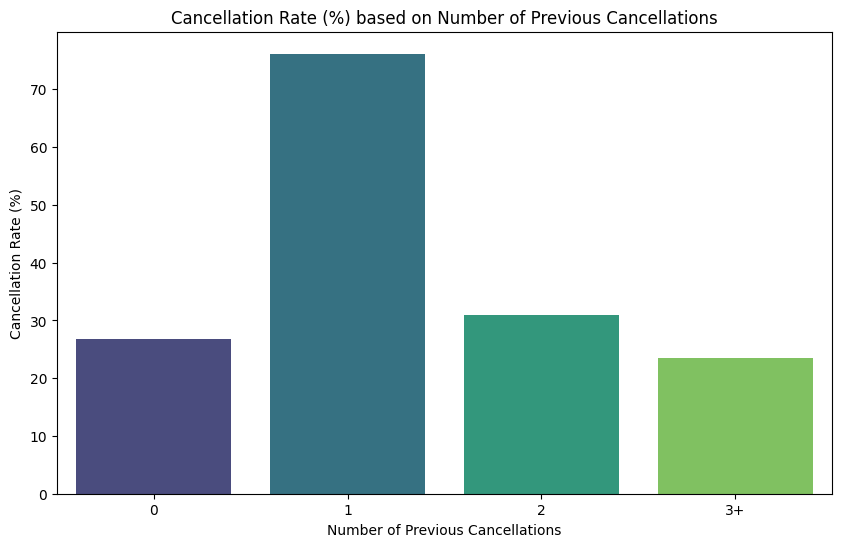

In [ ]:
print("\n-- Previous Cancellations Analysis --")
avg_prev_cancel = df.groupby('is_canceled')['previous_cancellations'].mean()
median_prev_cancel = df.groupby('is_canceled')['previous_cancellations'].median()
print("Average Previous Cancellations by Current Booking Status:")
print(avg_prev_cancel.round(2))
print("Median Previous Cancellations by Current Booking Status:")
print(median_prev_cancel)
print(f"0: Not Canceled, 1: Canceled")

# Bar Plot of Cancellation Rate grouped by Previous Cancellations
df['prev_cancel_group'] = df['previous_cancellations'].apply(lambda x: '3+' if x >= 3 else str(x))

cancellation_rate_by_prev_cancel = df.groupby('prev_cancel_group')['is_canceled'].mean() * 100
cancellation_rate_by_prev_cancel = cancellation_rate_by_prev_cancel.reset_index()
order = sorted(cancellation_rate_by_prev_cancel['prev_cancel_group'].unique(), key=lambda x: int(x.replace('+','')) if x != '0' else 0)

plt.figure(figsize=(10, 6))
sns.barplot(x='prev_cancel_group', y='is_canceled', data=cancellation_rate_by_prev_cancel, order=order, palette='viridis', hue = 'prev_cancel_group', legend=False)
plt.title('Cancellation Rate (%) based on Number of Previous Cancellations')
plt.xlabel('Number of Previous Cancellations')
plt.ylabel('Cancellation Rate (%)')
plt.show()

*One prior cancellation is a major red flag.*

# **Categorical Feature Analysis vs. Cancellation**


--- Step 3: Categorical Feature Analysis vs. Cancellation ---

-- Market Segment Analysis --
Booking Counts per Market Segment:
market_segment
Online TA        51553
Offline TA/TO    13855
Direct           11780
Groups            4921
Corporate         4200
Complementary      692
Aviation           226
Undefined            2
Name: count, dtype: int64


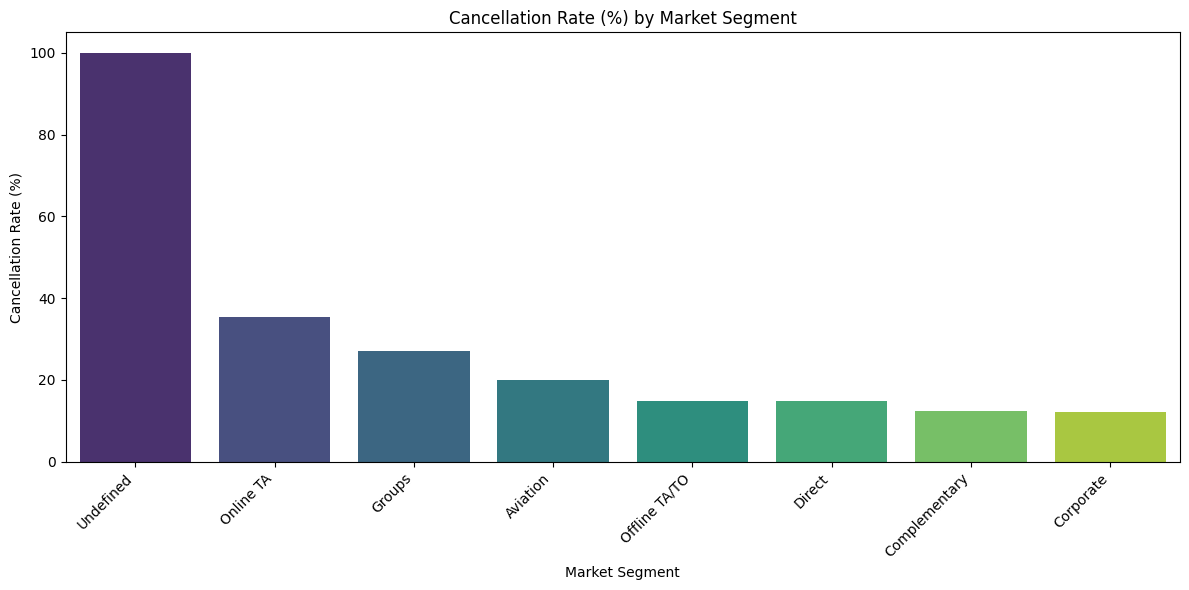


-- Market Segment Cancellation Rate by Hotel Type --


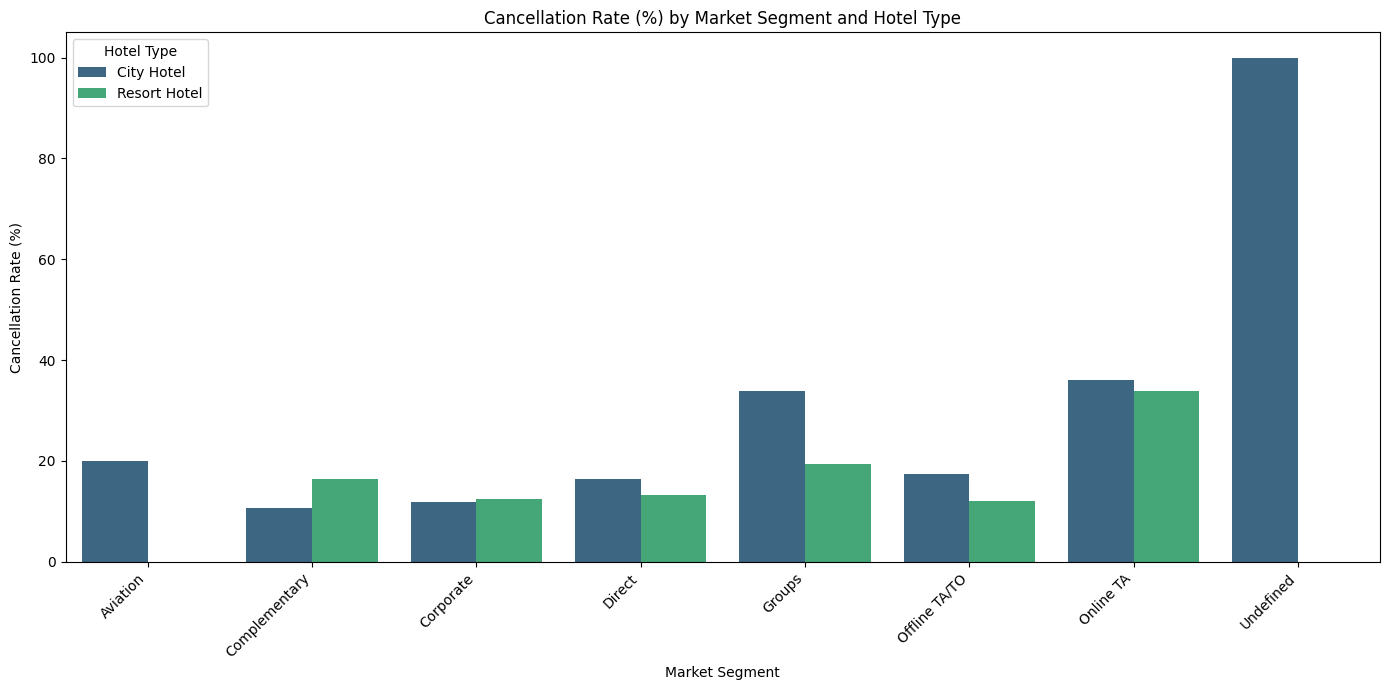

In [ ]:
print("\n--- Step 3: Categorical Feature Analysis vs. Cancellation ---")

def show_values_on_bars(axs, h_v="v", space=0.4):
    def _show_on_single_plot(ax):
        if h_v == "v":
            for p in ax.patches:
                _x = p.get_x() + p.get_width() / 2
                _y = p.get_y() + p.get_height() + space
                value = f"{p.get_height():.1f}%"
                ax.text(_x, _y, value, ha="center")
        elif h_v == "h":
            for p in ax.patches:
                _x = p.get_x() + p.get_width() + float(space)
                _y = p.get_y() + p.get_height() / 2
                value = f"{p.get_width():.1f}%" #
                ax.text(_x, _y, value, ha="left", va="center")

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)

print("\n-- Market Segment Analysis --")
cancellation_rate_market = df.groupby('market_segment')['is_canceled'].mean().reset_index()
cancellation_rate_market['is_canceled'] *= 100
cancellation_rate_market = cancellation_rate_market.sort_values(by='is_canceled', ascending=False)

print("Booking Counts per Market Segment:")
print(df['market_segment'].value_counts())

# Bar Chart of Cancellation Rate (%) per Market Segment
plt.figure(figsize=(12, 6))
ax1 = sns.barplot(x='market_segment', y='is_canceled', data=cancellation_rate_market, palette='viridis', hue = 'market_segment', legend=False, order = cancellation_rate_market['market_segment']) # Order bars
plt.title('Cancellation Rate (%) by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Market Segment Cancellation Rate by Hotel Type
print("\n-- Market Segment Cancellation Rate by Hotel Type --")
cancellation_rate_market_hotel = df.groupby(['hotel', 'market_segment'])['is_canceled'].mean().reset_index()
cancellation_rate_market_hotel['is_canceled'] *= 100

plt.figure(figsize=(14, 7))
ax2 = sns.barplot(x='market_segment', y='is_canceled', hue='hotel', data=cancellation_rate_market_hotel, palette='viridis')
plt.title('Cancellation Rate (%) by Market Segment and Hotel Type')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

**IGNORE UNDEFINED (ONLY 2 ROWS, NO MEANING)**

Online TA (Booking.com, Expedia, Agoda, etc) and Groups(conferences, events, tours, or weddings.) consistently shows high cancellation rates for both hotels.


--- Temporal Analysis (Seasonality) ---

-- Cancellation Rate by Arrival Month --
Converted 'arrival_date_month' to ordered categorical type.
Booking Counts per Arrival Month:
arrival_date_month
January       4685
February      6083
March         7488
April         7900
May           8344
June          7756
July         10043
August       11242
September     6682
October       6921
November      4973
December      5112
Name: count, dtype: int64


<ipython-input-47-b37b75d7afb1>:7: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(df['arrival_date_month']) or df['arrival_date_month'].cat.ordered == False:


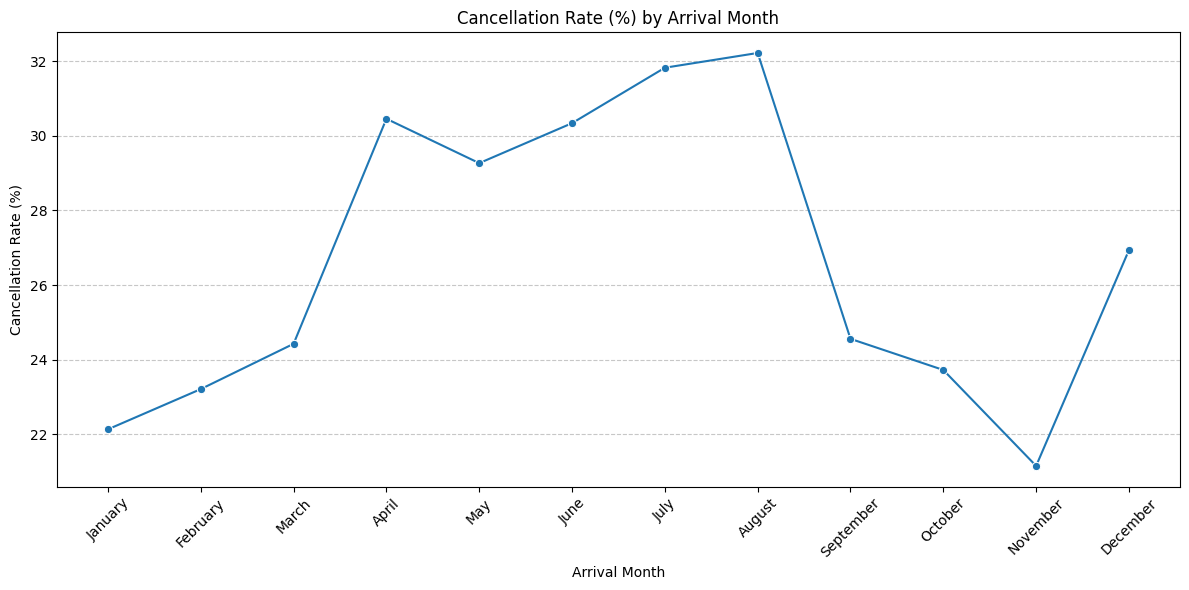

In [ ]:
print("\n--- Temporal Analysis (Seasonality) ---")
print("\n-- Cancellation Rate by Arrival Month --")

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

if not pd.api.types.is_categorical_dtype(df['arrival_date_month']) or df['arrival_date_month'].cat.ordered == False:
     try:
          df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)
          print("Converted 'arrival_date_month' to ordered categorical type.")
     except Exception as e:
          print(f"Could not convert month column to ordered categorical: {e}")


cancellation_rate_month = df.groupby('arrival_date_month', observed=False)['is_canceled'].mean().reset_index()
cancellation_rate_month['is_canceled'] *= 100

print("Booking Counts per Arrival Month:")
print(df['arrival_date_month'].value_counts().sort_index())

# Line Plot/Bar Chart of Cancellation Rate (%) by Month
plt.figure(figsize=(12, 6))
ax_month = sns.lineplot(x='arrival_date_month', y='is_canceled', data=cancellation_rate_month, sort=False, marker='o') # sort=False because it's ordered categorical
plt.title('Cancellation Rate (%) by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

*High Season = High Cancellation Risk*


-- Car Parking Space Analysis --
Booking Counts by Required Parking Spaces (0=No, 1=Yes):
required_car_parking_spaces
0    79923
1     7273
Name: count, dtype: int64


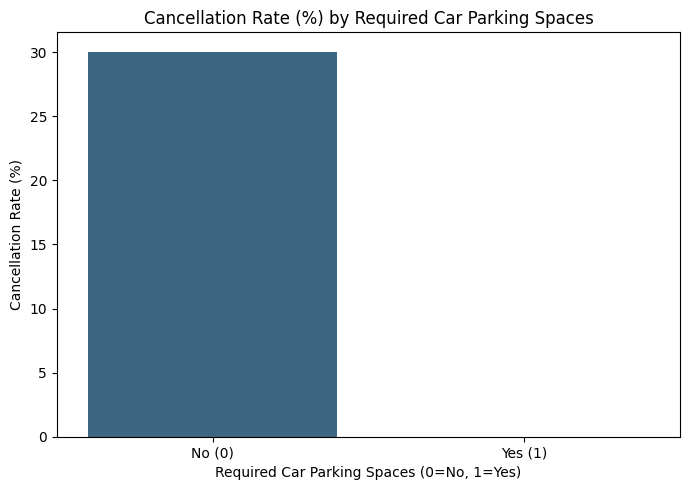


-- Special Requests Analysis --
Booking Counts by Number of Special Requests:
total_of_special_requests
0    43788
1    28976
2    11795
3     2314
4      320
5       36
Name: count, dtype: int64


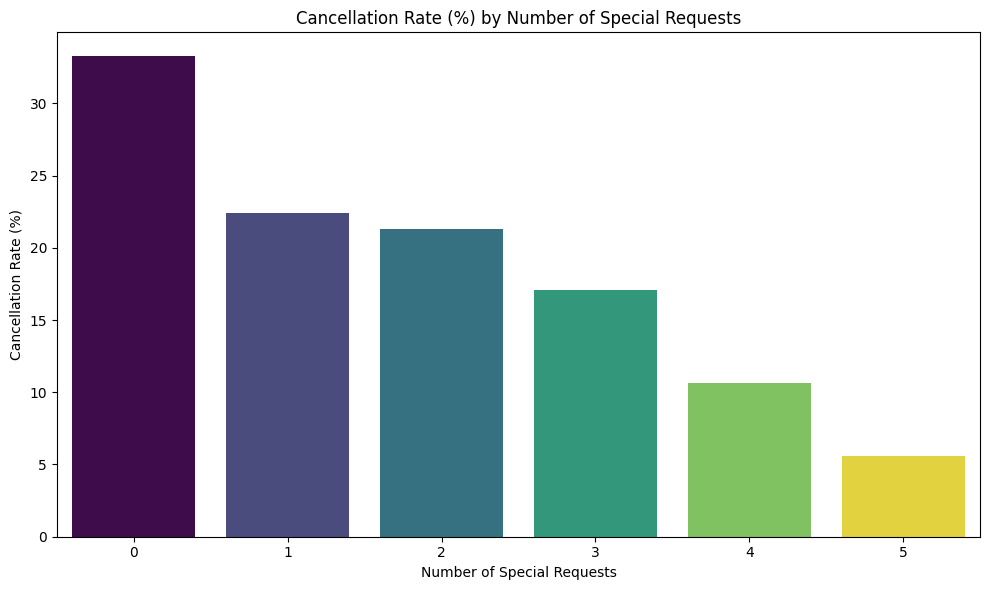

In [ ]:
print("\n-- Car Parking Space Analysis --")
parking_df = df[df['required_car_parking_spaces'].isin([0, 1])]
cancellation_rate_parking = parking_df.groupby('required_car_parking_spaces')['is_canceled'].mean().reset_index()
cancellation_rate_parking['is_canceled'] *= 100

print("Booking Counts by Required Parking Spaces (0=No, 1=Yes):")
print(parking_df['required_car_parking_spaces'].value_counts())

plt.figure(figsize=(7, 5))
ax_park = sns.barplot(x='required_car_parking_spaces', y='is_canceled', data=cancellation_rate_parking, palette='viridis', hue='required_car_parking_spaces', legend=False)
plt.title('Cancellation Rate (%) by Required Car Parking Spaces')
plt.xlabel('Required Car Parking Spaces (0=No, 1=Yes)')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(ticks=[0, 1], labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

print("\n-- Special Requests Analysis --")
cancellation_rate_requests = df.groupby('total_of_special_requests')['is_canceled'].mean().reset_index()
cancellation_rate_requests['is_canceled'] *= 100

print("Booking Counts by Number of Special Requests:")
print(df['total_of_special_requests'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
ax_req = sns.barplot(x='total_of_special_requests', y='is_canceled', data=cancellation_rate_requests, palette='viridis', hue='total_of_special_requests', legend=False)
plt.title('Cancellation Rate (%) by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()


*Need for parking space = 0% cancelation rate*

*More special requets = Less cancelation rate*

In [ ]:
print("\n-- Summary Statistics for Numerical Columns --")
pd.options.display.float_format = '{:.2f}'.format
print(df.describe())

print("\n-- Summary Statistics for Categorical Columns --")
include_types = ['object']
if any(isinstance(dtype, pd.CategoricalDtype) for dtype in df.dtypes):
    include_types.append('category')
print(df.describe(include=include_types))


-- Summary Statistics for Numerical Columns --
       is_canceled  lead_time  arrival_date_year  arrival_date_week_number  \
count     87229.00   87229.00           87229.00                  87229.00   
mean          0.28      79.97            2016.21                     26.84   
min           0.00       0.00            2015.00                      1.00   
25%           0.00      11.00            2016.00                     16.00   
50%           0.00      49.00            2016.00                     27.00   
75%           1.00     125.00            2017.00                     37.00   
max           1.00     737.00            2017.00                     53.00   
std           0.45      86.06               0.69                     13.67   

       arrival_date_day_of_month  stays_in_weekend_nights  \
count                   87229.00                 87229.00   
mean                       15.82                     1.00   
min                         1.00                     0.00   
25%  

## **Conclusion**

Our analysis of the Hotel Booking Demand dataset confirms that booking cancellations represent a substantial challenge, with an overall rate of approximately 27.5%.

Several factors emerged as strong indicators of cancellation risk:
*   lead_time:  This is a primary driver. Bookings made further in advance are significantly more likely to be canceled.
*   Customer History (previous_cancellations, is_repeated_guest): Having exactly one prior cancellation dramatically increases the risk for the current booking (75% rate). Conversely, being a repeat guest drastically lowers the cancellation risk (8% rate)
*   Guest Engagement (total_of_special_requests required_car_parking_spaces): Guests who engage more by making special requests or requiring logistical necessities like parking demonstrate significantly higher commitment and lower cancellation rates. Zero requests correlate with the highest cancellation risk (~33%), while needing parking correlates with near-zero cancellations.
*   Seasonality (arrival_date_month): Cancellation risk peaks during the high travel season (April-August) and dips in the late autumn/early winter (lowest in November).


# **Insights**

1. **Implement Dynamic Deposit & Payment Policies:**
  *   Long Lead Times: Consider requiring mandatory deposits (refundable or non-refundable) or full pre-payment for bookings made significantly far in advance (e.g., > 120-180 days, threshold to be determined).
  *   High-Risk Segments: Apply stricter deposit rules (e.g., non-refundable options, larger deposit amounts) specifically for bookings identified as high-risk:
    *   Guests with exactly one previous cancellation.
    *   Bookings via Online TA.
    *   Groups bookings, especially at the City Hotel.
2. **Optimize Channel Management & Marketing:**
  *  Drive Direct Bookings: Invest in enhancing the hotel's own website and booking engine. Offer 'Best Rate Guarantees' or small perks (e.g., free Wi-Fi, minor discount) for booking direct, emphasizing this lower-risk channel.  
3. **Leverage Customer History & Loyalty:**
  *  Flag High-Risk History: Implement systems to flag guests with exactly one prior cancellation for potentially stricter terms or careful monitoring.
  *  Reward Repeat Guests: Acknowledge the significantly lower risk posed by repeat guests. Enhance loyalty programs and consider offering them slightly more flexible terms as a reward, reinforcing their loyalty.

